In [8]:
import numpy as np
import matplotlib.pyplot as plt
from astroquery.gaia import Gaia

In [9]:
query = """
SELECT TOP 100
    source_id, ra, dec, parallax, phot_g_mean_mag,
    teff_gspphot, logg_gspphot, mh_gspphot
FROM gaiadr3.gaia_source
WHERE mh_gspphot < -2.0
AND teff_gspphot BETWEEN 4000 AND 7000
AND parallax > 0
"""

job = Gaia.launch_job(query)
results = job.get_results()
print(f"Stars found: {len(results)}")
print(results[:5])

Stars found: 100
   source_id            ra         ...  logg_gspphot mh_gspphot
                       deg         ... log(cm.s**-2)    dex    
--------------- ------------------ ... ------------- ----------
 35115652874752  44.99106740350177 ...        4.6842    -2.5412
 69647190025088  45.29289046421254 ...        4.8751    -2.0404
137129716240128  44.97968539841983 ...        4.6122    -2.4907
141733920781568 45.765263586406455 ...        4.8796    -2.0615
214473487196544  45.38062369127864 ...        4.6349    -2.0393


**100 metal poor stars pulled from the real Gaia database.**

Look at the mh_gspphot column — those are metallicity values in dex. The sun is 0.0 by definition. These stars are at -2.0 to -2.5, meaning they have 100 to 300 times less iron than the sun. Ancient, chemically primitive stars.
logg_gspphot is surface gravity — tells you if it's a dwarf or a giant. Around 4.5 means dwarf star, similar size to the sun. Lower values mean giant.

**Sky Distribution**

Plotting RA and Dec of our metal poor star sample, coloured by metallicity. 
Metal poor stars are halo objects — ancient stars formed before the galactic disk existed. 
Expect them scattered across the sky rather than concentrated along the galactic plane.


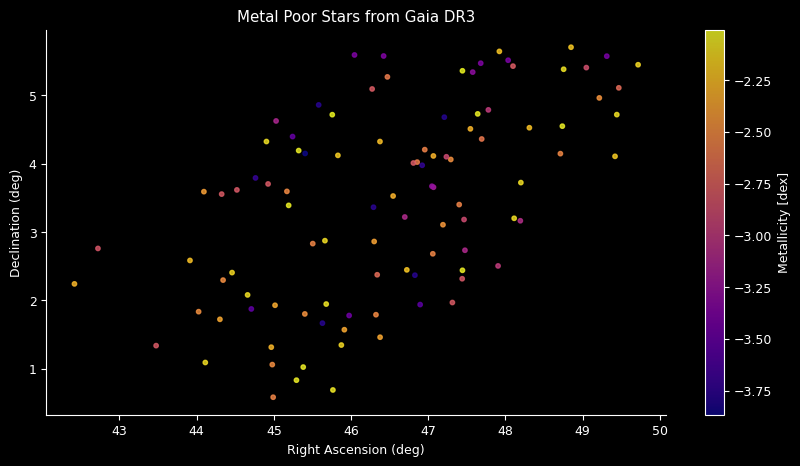

In [10]:

plt.figure(figsize=(10, 5))
plt.scatter(results['ra'], results['dec'], 
            c=results['mh_gspphot'], cmap='plasma',
            s=10, alpha=0.8)
plt.colorbar(label='Metallicity [dex]')
plt.xlabel('Right Ascension (deg)')
plt.ylabel('Declination (deg)')
plt.title('Metal Poor Stars from Gaia DR3')
plt.savefig('plots/sky_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

##### Expanding the Sample
Our first query returned stars from a small sky patch. Gaia returns results 
in database order, not sky order. We need to sample randomly across the whole 
sky to see the true distribution of metal poor halo stars.

In [11]:
query = """
SELECT TOP 500
    source_id, ra, dec, parallax, phot_g_mean_mag,
    teff_gspphot, logg_gspphot, mh_gspphot
FROM gaiadr3.gaia_source
WHERE mh_gspphot < -2.0
AND teff_gspphot BETWEEN 4000 AND 7000
AND parallax > 0
AND ra BETWEEN 0 AND 360
AND dec BETWEEN -90 AND 90
"""

job = Gaia.launch_job(query)
results = job.get_results()
print(f"Stars found: {len(results)}")

Stars found: 500


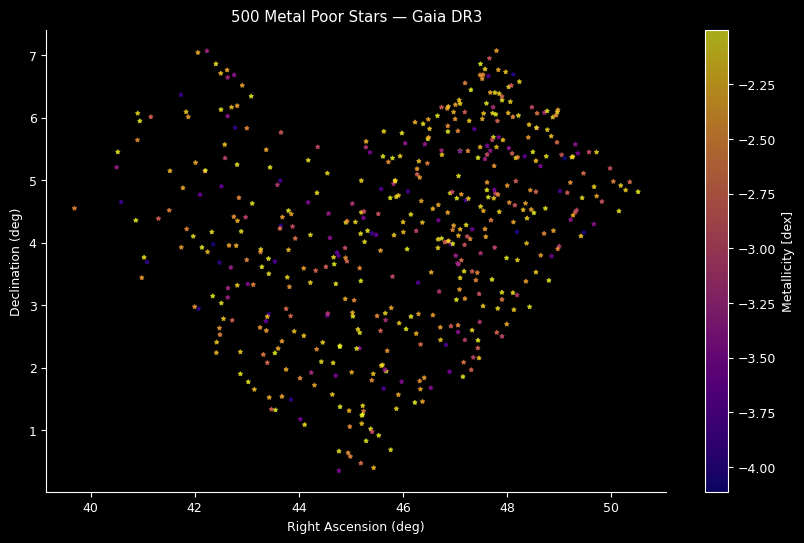

In [12]:
plt.style.use('dark_background')
plt.figure(figsize=(10, 6))
plt.scatter(results['ra'], results['dec'],
            c=results['mh_gspphot'], cmap='plasma',
            s=8, alpha=0.7,marker="*")
plt.colorbar(label='Metallicity [dex]')
plt.xlabel('Right Ascension (deg)')
plt.ylabel('Declination (deg)')
plt.title('500 Metal Poor Stars — Gaia DR3')
plt.savefig('plots/metallicity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

#### Metallicity Distribution

How many stars at each metallicity level? The shape of this histogram 
tells us about the chemical enrichment history of the early galaxy.
Most stars cluster just below -2.0 — truly extreme metal poor stars 
(below -3.0) are rare because the early universe enriched quickly.

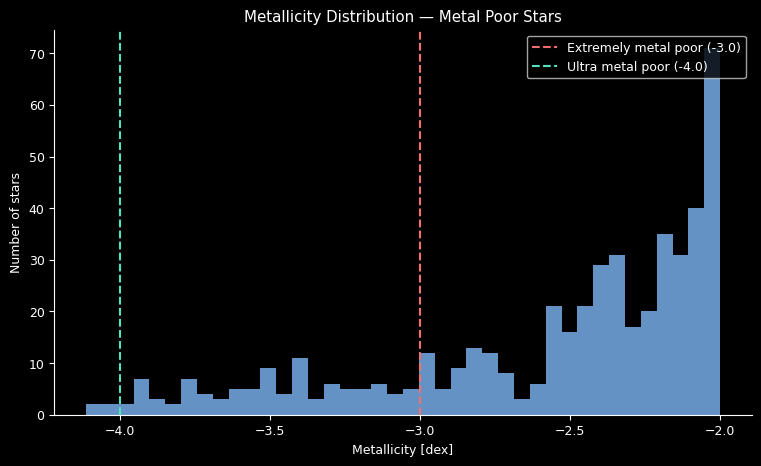

Stars below -3.0: 102
Stars below -4.0: 4


In [13]:
plt.style.use('dark_background')
plt.figure(figsize=(9, 5))
plt.hist(results['mh_gspphot'], bins=40, 
         color='#7EB8F7', edgecolor='none', alpha=0.8)
plt.axvline(x=-3.0, color='#F76E6E', linestyle='--', label='Extremely metal poor (-3.0)')
plt.axvline(x=-4.0, color='#50E3C2', linestyle='--', label='Ultra metal poor (-4.0)')
plt.xlabel('Metallicity [dex]')
plt.ylabel('Number of stars')
plt.title('Metallicity Distribution — Metal Poor Stars')
plt.legend()
plt.savefig('plots/metallicity_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Stars below -3.0: {(results['mh_gspphot'] < -3.0).sum()}")
print(f"Stars below -4.0: {(results['mh_gspphot'] < -4.0).sum()}")

#### The Most Extreme Stars

Isolating the 6 ultra metal poor stars (below -4.0 dex). These are 
among the oldest stars in the galaxy — formed when the universe had 
barely any heavy elements. Each one is a direct window into the 
conditions of the early universe.

In [14]:
ump = results[results['mh_gspphot'] < -4.0]

print("Ultra metal poor stars:")
print(f"{'Source ID':<20} {'RA':>8} {'Dec':>8} {'Temp (K)':>10} {'log g':>8} {'[M/H]':>8}")
print("-" * 70)
for star in ump:
    print(f"{star['source_id']:<20} {star['ra']:>8.3f} {star['dec']:>8.3f} {star['teff_gspphot']:>10.0f} {star['logg_gspphot']:>8.3f} {star['mh_gspphot']:>8.3f}")

Ultra metal poor stars:
Source ID                  RA      Dec   Temp (K)    log g    [M/H]
----------------------------------------------------------------------
4942923242391424       42.356    3.974       5760    4.664   -4.072
2870210680420992       49.478    4.163       5635    4.389   -4.048
2723769475558016       48.192    4.176       5554    4.709   -4.051
3318704049875072       49.108    5.350       5965    4.720   -4.113


#### Temperature-Metallicity Relationship

Plotting all 500 stars — temperature vs metallicity. 
Do the most metal poor stars have any systematic temperature pattern?
If ancient stars cluster at specific temperatures it tells us about 
stellar evolution timescales — only certain types survive long enough 
to still be visible today.

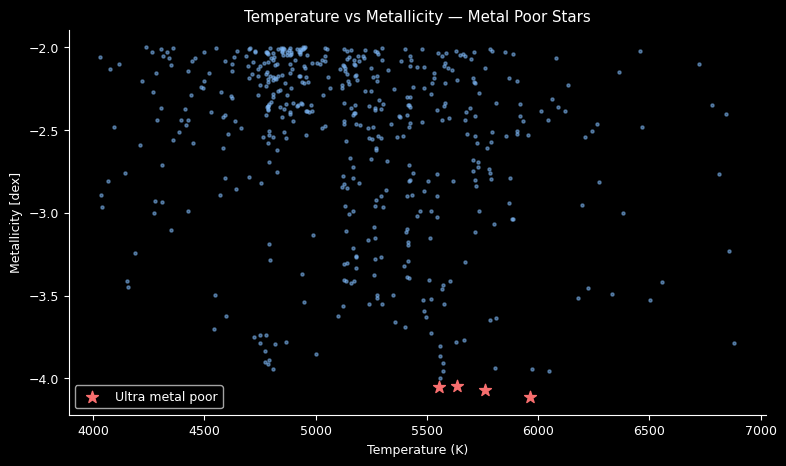

In [15]:

plt.figure(figsize=(9, 5))
plt.scatter(results['teff_gspphot'], results['mh_gspphot'],
            s=5, alpha=0.5, color='#7EB8F7')
plt.scatter(ump['teff_gspphot'], ump['mh_gspphot'],
            s=80, color='#F76E6E', zorder=5, label='Ultra metal poor',marker = "*")
plt.xlabel('Temperature (K)')
plt.ylabel('Metallicity [dex]')
plt.title('Temperature vs Metallicity — Metal Poor Stars')
plt.legend()
plt.savefig('plots/temp_vs_metallicity.png', dpi=150, bbox_inches='tight')
plt.show()

#### Hertzsprung-Russell Diagram

Temperature vs surface gravity — a proxy for the HR diagram.
High log g = dwarf star (main sequence). Low log g = giant star.
Metal poor stars should sit on the main sequence — confirming 
they are old, stable, long lived stars still burning hydrogen.

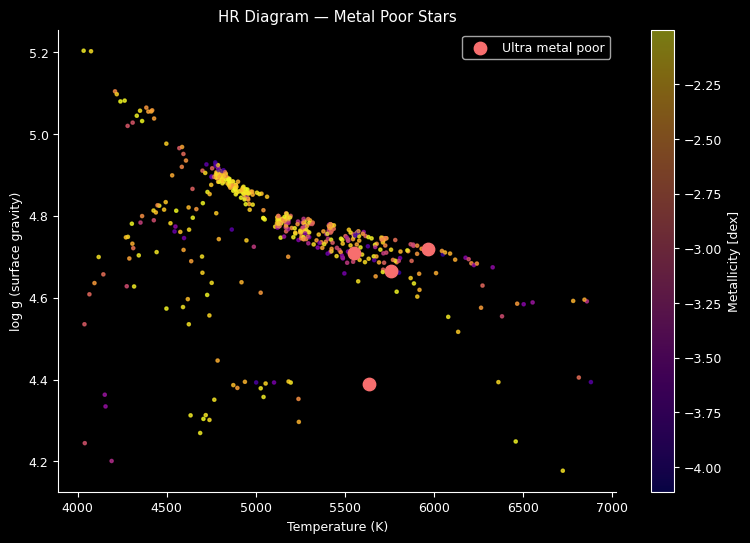

In [16]:

plt.style.use('dark_background')
plt.figure(figsize=(9, 6))
plt.scatter(results['teff_gspphot'], results['logg_gspphot'],
            c=results['mh_gspphot'], cmap='plasma',
            s=5, alpha=0.5)
plt.scatter(ump['teff_gspphot'], ump['logg_gspphot'],
            s=80, color='#F76E6E', zorder=5, label='Ultra metal poor')
sc = plt.scatter(results['teff_gspphot'], results['logg_gspphot'],
            c=np.array(results['mh_gspphot']), cmap='plasma',
            s=5, alpha=0.5)
plt.colorbar(sc, label='Metallicity [dex]')
plt.xlabel('Temperature (K)')
plt.ylabel('log g (surface gravity)')
plt.title('HR Diagram — Metal Poor Stars')
plt.savefig('plots/HR_diagram.png', dpi=150, bbox_inches='tight')
plt.legend()
plt.show()

In [17]:
query = """
SELECT TOP 500
    source_id, ra, dec, pmra, pmdec,
    teff_gspphot, logg_gspphot, mh_gspphot
FROM gaiadr3.gaia_source
WHERE mh_gspphot < -2.0
AND teff_gspphot BETWEEN 4000 AND 7000
AND parallax > 0
AND pmra IS NOT NULL
AND pmdec IS NOT NULL
"""

job = Gaia.launch_job(query)
results2 = job.get_results()
print(f"Stars with proper motion: {len(results2)}")

Stars with proper motion: 500


#### Proper Motion

pmra and pmdec are how fast each star moves across the sky in RA and Dec 
directions, in milliarcseconds per year. Halo stars have high, scattered 
velocities in all directions — chaotic orbits. Disk stars cluster near zero 
— ordered circular orbits. Metal poor halo stars should show high scatter.

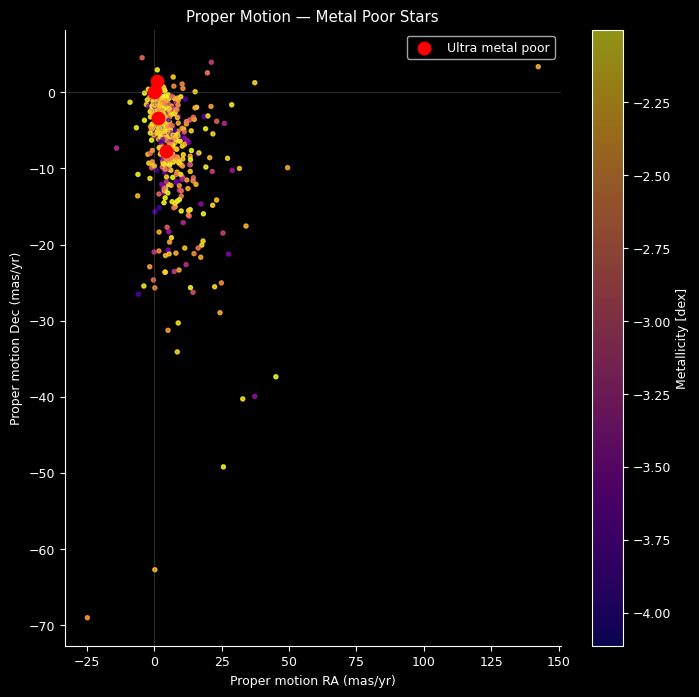

In [18]:
ump2 = results2[results2['mh_gspphot'] < -4.0]

plt.figure(figsize=(8, 8))
plt.scatter(results2['pmra'], results2['pmdec'],
            c=np.array(results2['mh_gspphot']), cmap='plasma',
            s=8, alpha=0.6)
plt.scatter(ump2['pmra'], ump2['pmdec'],
            s=80, color='red', zorder=5, label='Ultra metal poor')
sc = plt.scatter(results2['pmra'], results2['pmdec'],
            c=np.array(results2['mh_gspphot']), cmap='plasma',
            s=8, alpha=0.6)
plt.colorbar(sc, label='Metallicity [dex]')
plt.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
plt.axvline(0, color='gray', linewidth=0.5, alpha=0.5)
plt.xlabel('Proper motion RA (mas/yr)')
plt.ylabel('Proper motion Dec (mas/yr)')
plt.title('Proper Motion — Metal Poor Stars')
plt.savefig('plots/proper_motion.png', dpi=150, bbox_inches='tight')
plt.legend()
plt.show()

#### Proper Motion Speed vs Metallicity

Total proper motion speed — combining RA and Dec components.
Halo stars should show higher speeds than disk stars.
Expect the most metal poor stars to have higher velocities —
they're on chaotic ancient orbits, not the ordered disk.

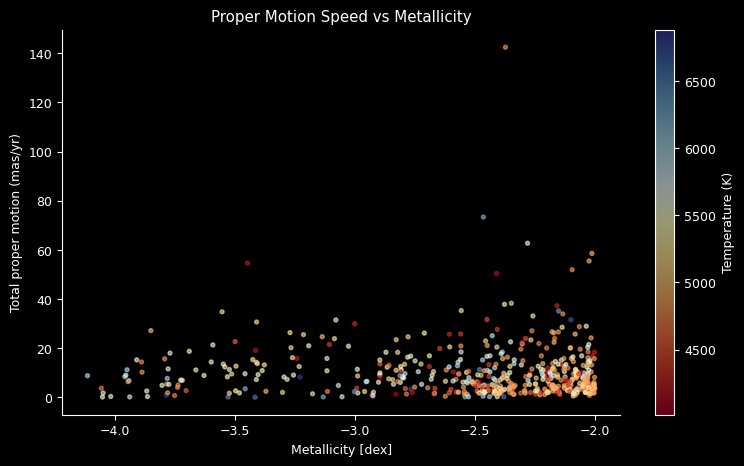

Median proper motion: 7.8 mas/yr
Ultra metal poor median: 1.8 mas/yr


In [19]:
pm_total = np.sqrt(np.array(results2['pmra'])**2 + np.array(results2['pmdec'])**2)

plt.figure(figsize=(9, 5))
sc = plt.scatter(results2['mh_gspphot'], pm_total,
            c=np.array(results2['teff_gspphot']), cmap='RdYlBu',
            s=8, alpha=0.6)
plt.colorbar(sc, label='Temperature (K)')
plt.xlabel('Metallicity [dex]')
plt.ylabel('Total proper motion (mas/yr)')
plt.title('Proper Motion Speed vs Metallicity')
plt.savefig('plots/proper_motion_speed_vs_metallicity.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Median proper motion: {np.median(pm_total):.1f} mas/yr")
print(f"Ultra metal poor median: {np.median(np.sqrt(np.array(ump2['pmra'])**2 + np.array(ump2['pmdec'])**2)):.1f} mas/yr")